## Notebook for reading in baseline files, computing the 75th percentile temps, saving it out

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt
import dask
import dask.array as da
import xarray as xr
from dask.diagnostics import ProgressBar
from dask.utils import format_bytes

In [8]:
#import sys
#!conda install --yes --prefix {sys.prefix} dask

In [4]:
!ls -al '../../../Data/ERA5-global/Baseline/'

total 16320
drwxr-xr-x@ 34 tedscott  staff     1088 Aug 29 13:44 .
drwxr-xr-x@  8 tedscott  staff      256 Aug  9 11:11 ..
-rw-r--r--@  1 tedscott  staff    18436 Aug 29 13:43 .DS_Store
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 11:30 1961
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 12:14 1962
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 13:04 1963
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 13:49 1964
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 14:39 1965
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 15:32 1966
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 16:36 1967
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 09:09 1968
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 10:17 1969
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 11:13 1970
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 12:10 1971
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 13:03 1972
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 13:56 1973
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 14:45 1974
dr

In [5]:

file_path = '../../../Data/ERA5-global/Baseline/*/download_daily_mean_sea_surface_temperature_*.nc'

# open without dask chunking and see if it crashes
#ds = xr.open_mfdataset(file_path) #, chunks={'time': 10})

# chunking but will likely have to load it all for quantile calc
ds = xr.open_mfdataset(file_path)#, chunks={'latitude': 10, 'longitude': 10})

In [6]:
ds.nbytes

45504087672

In [7]:
ds

<xarray.Dataset> Size: 46GB
Dimensions:      (time: 10957, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 88kB 1961-01-01 1961-01-02 ... 1990-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    sst          (time, lat, lon) float32 46GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-08-27T17:32 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [8]:
np.unique(ds.time.dt.year.values)

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990])

In [9]:
%%time
# load it into memory because I can't do quantile on on the dask dataset (also can't figure out how to do percentile)
ds.load()

CPU times: user 3.64 s, sys: 25.7 s, total: 29.3 s
Wall time: 1min 51s


<xarray.Dataset> Size: 46GB
Dimensions:      (time: 10957, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 88kB 1961-01-01 1961-01-02 ... 1990-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    sst          (time, lat, lon) float32 46GB nan nan nan ... 271.5 271.5 271.5
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-08-27T17:32 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [10]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
c_75 = ds.sst.quantile(0.75, dim=('time'), keep_attrs=True, skipna=True)
#c_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
#c_75.attrs["units"] = "K"
c_75

/Users/tedscott/anaconda3/envs/climate/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


CPU times: user 1min 32s, sys: 15.5 s, total: 1min 48s
Wall time: 2min 50s


<xarray.DataArray 'sst' (lat: 721, lon: 1440)> Size: 4MB
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [271.46042, 271.46042, 271.46042, ..., 271.46042, 271.46042,
        271.46042],
       [271.46042, 271.46042, 271.46042, ..., 271.4601 , 271.46042,
        271.46042],
       [271.46042, 271.46042, 271.46042, ..., 271.46042, 271.46042,
        271.46042]], dtype=float32)
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B 0.75
Attributes:
    long_name:      Sea surface temperature
    units:          K
    standard_name:  sea_surface_temperature
    comment:        Temperature of upper boundary of the liquid ocean, includ...
    type:           real

### assuming everything looks good, then the next cell writes it out

In [11]:
#'../../../Data/ERA5-global/Baseline/*/*.nc'
c_75.to_netcdf("../../../Data/ERA5-global/Baseline/computed_SST_1961-1990-full_75th.nc")

### and hopfully this closes the objects to free up memory

In [12]:
ds.close()
c_75.close()

In [13]:
! ls -l "../../../Data/ERA5-global/Baseline/"

total 24456
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 11:30 1961
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 12:14 1962
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 13:04 1963
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 13:49 1964
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 14:39 1965
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 15:32 1966
drwxr-xr-x@ 26 tedscott  staff      832 Aug 27 16:36 1967
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 09:09 1968
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 10:17 1969
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 11:13 1970
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 12:10 1971
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 13:03 1972
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 13:56 1973
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 14:45 1974
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 15:31 1975
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 16:21 1976
drwxr-xr-x@ 26 tedscott  staff      832 Aug 28 17:06 1977
dr

Text(0.5, 1.0, '75th Percentile SST from 1961 - 1990')

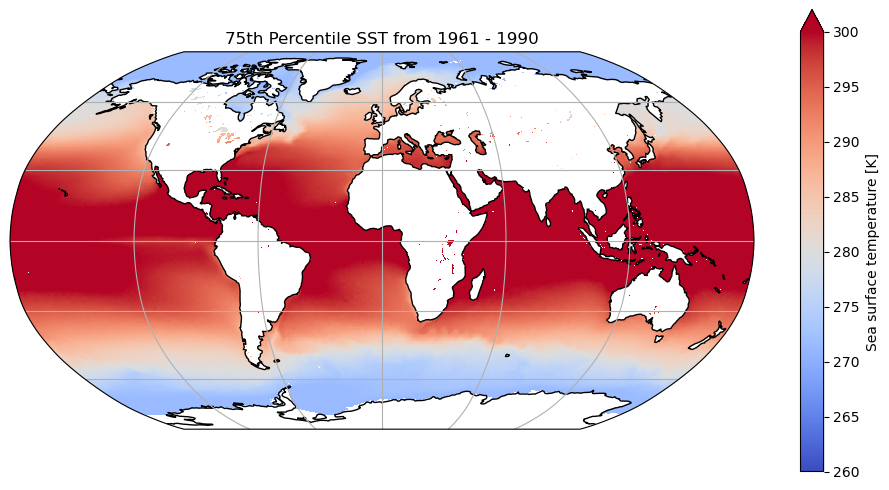

In [14]:
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

# plot first index of SSTs
c_75.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=260,
    vmax=300, # define temp range for colorbar 230 to 310 K
    cmap="coolwarm"
)

plt.title("75th Percentile SST from 1961 - 1990")

<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_1642/1667559701.py:20: SyntaxWarning: invalid escape sequence '\c'
  fig.colorbar(dataplot, orientation="vertical", label="Temperature ($^\circ C$)",


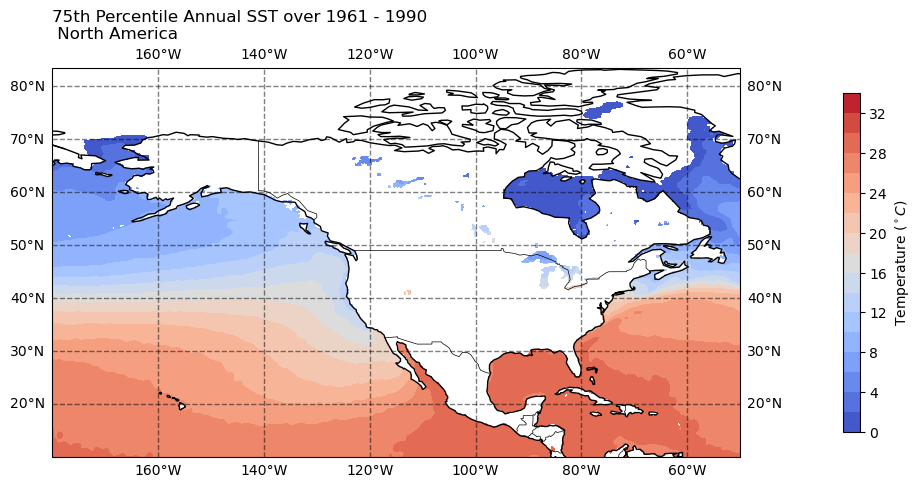

In [16]:
# make a north america map too

# try another way of plotting
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree())  
ax.set_title("75th Percentile Annual SST over 1961 - 1990 \n North America", loc="left")
dataplot = ax.contourf(
    c_75.lon,
    c_75.lat,
    c_75-273.15,
    levels=np.arange(0,35,2),
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.coolwarm,
)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
ax.set_extent((-180, -50, 10, 75))
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
fig.colorbar(dataplot, orientation="vertical", label="Temperature ($^\circ C$)",
             shrink=0.55, pad=0.11
            )